# Clustering jerárquico con Silhouette

Este notebook realiza clustering jerárquico sobre `Dataset/data_preprocesada.csv` sin variable target.

Flujo:
1. Cargar y preparar datos numéricos.
2. Estandarizar variables.
3. Evaluar número de clusters con métrica **Silhouette**.
4. Entrenar modelo jerárquico final.
5. Guardar artefacto `.pkl` en `Models/clustering_jerarquico.pkl`.


In [1]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)


In [2]:
# Rutas
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'Models' else Path.cwd().resolve()
DATA_PATH = ROOT / 'Dataset' / 'data_preprocesada.csv'
MODEL_PATH = ROOT / 'Models' / 'clustering_jerarquico.pkl'

print(f'Data path: {DATA_PATH}')
print(f'Model path: {MODEL_PATH}')


Data path: /Users/miilwaukee/Documents/ciencia_de_datos/ciencia_de_datos/Dataset/data_preprocesada.csv
Model path: /Users/miilwaukee/Documents/ciencia_de_datos/ciencia_de_datos/Models/clustering_jerarquico.pkl


In [3]:
# Carga de datos
df = pd.read_csv(DATA_PATH)
print('Shape original:', df.shape)
print('Columnas:', len(df.columns))
df.head(3)


Shape original: (200000, 39)
Columnas: 39


,age,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,academic_performance,work_productivity,multiplayer_ratio,toxic_exposure,violent_games_ratio,mobile_gaming_ratio,night_gaming_ratio,weekend_gaming_hours,friends_gaming_count,online_friends,streaming_hours,esports_interest,headset_usage,microtransactions_spending,parental_supervision,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality,gaming_intensity_index,online_social_ratio,gaming_screen_share,gender_Female,gender_Male,gender_Other,addiction_class,addiction_level_original,partition
0,1.106716,-1.646065,-0.113295,0.180454,0.694010,-1.156370,-0.514881,-0.944476,-0.866113,-0.077578,0.494208,-0.493029,-1.473080,0.548159,-1.205205,-0.807595,-1.088860,-0.316046,-0.443108,0.579753,-1.269294,1.0,2.636096,-1.583714,-1.079957,-0.848070,0.358027,0.408814,1.057543,1.565007,-0.421056,-0.289764,1.272006,1,0,0,bajo,2.02,train
1,0.369081,-0.908864,0.623986,1.244874,0.555363,1.463923,-0.672478,-0.283464,0.872712,-2.161633,-1.694914,-1.208658,0.534230,0.148365,-1.160560,-0.807595,2.910225,0.863591,-1.586484,-0.469067,0.948754,1.0,-0.321155,0.632438,0.593630,-0.349886,0.894010,-0.011810,0.259967,-1.221489,1.433143,-0.467818,1.631113,1,0,0,moderado,5.85,train
2,-0.663607,-0.884648,-0.879776,-1.061369,1.387242,0.260185,0.136521,0.613624,-0.866113,1.867267,-1.026205,-1.969014,-0.845795,0.398236,-1.026622,-0.360200,-0.726192,1.418714,-0.720290,1.104163,0.948754,1.0,-0.919139,1.265625,0.287975,0.349138,-1.437013,0.378037,0.329322,1.565007,-1.050771,-0.411616,-1.482531,0,1,0,bajo,0.08,train


In [4]:
# Preparación de features (sin target)
# Se excluyen columnas no numéricas y columnas que representan clases/partición.
exclude_cols = ['addiction_class', 'addiction_level_original', 'partition']
existing_exclusions = [c for c in exclude_cols if c in df.columns]

df_model = df.drop(columns=existing_exclusions, errors='ignore')
X = df_model.select_dtypes(include=[np.number]).copy()

# Imputación robusta para evitar fallos por valores faltantes.
X = X.fillna(X.median(numeric_only=True))

print('Columnas excluidas:', existing_exclusions)
print('Shape para clustering:', X.shape)
print('Nulos totales en X:', int(X.isna().sum().sum()))


Columnas excluidas: ['addiction_class', 'addiction_level_original', 'partition']
Shape para clustering: (200000, 36)
Nulos totales en X: 0


In [5]:
# Muestreo para clustering jerárquico (escala O(n^2))
# Con 200k filas, se usa una muestra reproducible para hacer el proceso computacionalmente viable.
SAMPLE_SIZE = 5000
RANDOM_STATE = 42

if len(X) > SAMPLE_SIZE:
    X_sample = X.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
else:
    X_sample = X.copy()

print('Shape muestra:', X_sample.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)


Shape muestra: (5000, 36)


In [6]:
# Selección de k con Silhouette
k_values = list(range(2, 11))
silhouette_scores = []

for k in k_values:
    model_k = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_k = model_k.fit_predict(X_scaled)
    score_k = silhouette_score(X_scaled, labels_k)
    silhouette_scores.append(score_k)
    print(f'k={k} -> silhouette={score_k:.4f}')

silhouette_df = pd.DataFrame({'k': k_values, 'silhouette': silhouette_scores})
best_k = int(silhouette_df.loc[silhouette_df['silhouette'].idxmax(), 'k'])

print(f'\nMejor k según Silhouette: {best_k}')
silhouette_df


k=2 -> silhouette=0.0350


k=3 -> silhouette=0.0442


k=4 -> silhouette=0.0435


k=5 -> silhouette=0.0468


k=6 -> silhouette=0.0444


k=7 -> silhouette=0.0300


k=8 -> silhouette=0.0302


k=9 -> silhouette=0.0307


k=10 -> silhouette=0.0205

Mejor k según Silhouette: 5


,k,silhouette
0,2,0.035031
1,3,0.044171
2,4,0.043499
3,5,0.046794
4,6,0.044375
5,7,0.029995
6,8,0.030225
7,9,0.030716
8,10,0.020469


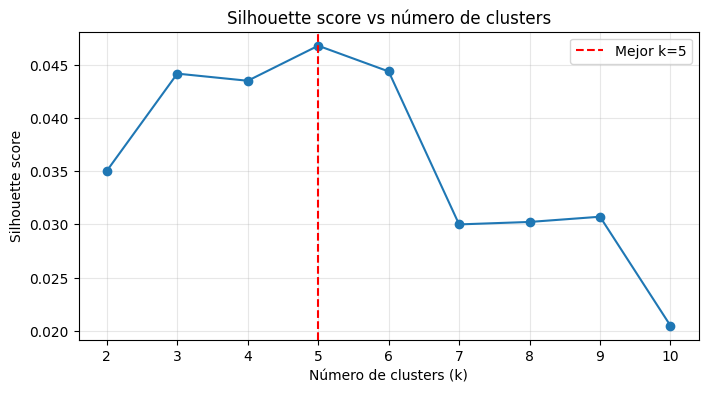

In [7]:
# Visualización de Silhouette por número de clusters
plt.figure(figsize=(8, 4))
plt.plot(silhouette_df['k'], silhouette_df['silhouette'], marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Mejor k={best_k}')
plt.title('Silhouette score vs número de clusters')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette score')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [8]:
# Entrenamiento final con el mejor k
final_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
final_labels = final_model.fit_predict(X_scaled)

cluster_counts = pd.Series(final_labels).value_counts().sort_index()
print('Distribución de clusters:')
print(cluster_counts)

clustered_sample = X_sample.copy()
clustered_sample['cluster'] = final_labels
clustered_sample.head()


Distribución de clusters:
0    2135
1    2137
2     214
3     430
4      84
Name: count, dtype: int64


,age,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,academic_performance,work_productivity,multiplayer_ratio,toxic_exposure,violent_games_ratio,mobile_gaming_ratio,night_gaming_ratio,weekend_gaming_hours,friends_gaming_count,online_friends,streaming_hours,esports_interest,headset_usage,microtransactions_spending,parental_supervision,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality,gaming_intensity_index,online_social_ratio,gaming_screen_share,gender_Female,gender_Male,gender_Other,cluster
119737,0.664135,0.009876,-0.054897,-1.150070,0.555363,-0.697486,0.388677,-1.007430,1.568241,-0.118322,-1.293553,1.027682,0.596959,-0.201454,-2.053474,0.937248,-1.303053,1.279933,-0.512404,-1.000563,0.948754,0.0,-0.002346,-1.267120,-0.791840,-0.696789,0.241728,-1.130054,-1.023089,0.868383,-0.426647,-0.393905,1.022339,1,0,0,1
72272,0.590372,0.774424,2.186148,-1.504877,0.555363,-0.371612,-0.866848,-0.430356,0.524947,-1.631961,-1.858861,-1.924287,-0.343968,0.997926,0.000229,-0.986554,1.401136,0.100296,-0.685643,0.168729,-1.269294,1.0,1.584841,-0.000748,-0.198067,0.883839,-2.190423,0.726847,0.017227,0.520071,2.495481,-0.359758,1.713413,0,1,0,3
158154,-0.368553,1.722305,-1.120670,0.801365,1.525888,-0.630981,-0.346777,-0.797585,-1.213878,-1.604798,-0.296951,-0.716664,-0.971252,-0.001557,-0.490874,-0.897075,-0.042234,0.724810,-1.240007,-0.164342,-0.001838,0.0,2.186635,-0.000748,-0.859485,-1.093250,-1.098231,-0.611968,1.404315,-1.221489,-1.085017,-0.437381,-1.148525,0,1,0,0
65426,-1.401241,-0.170898,0.251696,-0.617861,1.525888,1.410720,2.185286,-0.655939,0.872712,0.905710,-2.289474,-0.314122,-0.657610,0.298288,1.473539,-0.002283,-0.911177,-0.246656,1.545673,-1.227335,-0.001838,0.0,-0.409393,-1.267120,0.646242,-0.000374,-0.511683,1.178248,1.161574,0.868383,-0.020582,-0.018694,0.400821,1,0,0,1
30074,1.623060,0.851305,-0.168044,-1.593579,-0.969748,0.911933,-0.425576,-0.335926,0.872712,-0.954253,0.415296,-1.029751,-0.093054,0.148365,-0.848040,0.579331,-0.302673,-0.593608,-0.727220,-0.001350,-1.586158,1.0,-0.899732,-0.633934,1.370294,-0.529858,-1.138682,-0.386268,-0.745671,0.868383,-0.247727,-0.296791,0.433882,0,1,0,0


In [9]:
# Persistencia del modelo y metadatos
artifact = {
    'model': final_model,
    'scaler': scaler,
    'best_k': best_k,
    'silhouette_scores': silhouette_df,
    'feature_columns': X.columns.tolist(),
    'sample_index': X_sample.index.to_list(),
    'sample_size': int(len(X_sample)),
    'random_state': RANDOM_STATE,
    'method': 'AgglomerativeClustering(linkage=ward)'
}

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(artifact, MODEL_PATH)

print(f'Artefacto guardado en: {MODEL_PATH}')
print(f'Tamaño muestra usada: {len(X_sample)} de {len(X)} filas')


Artefacto guardado en: /Users/miilwaukee/Documents/ciencia_de_datos/ciencia_de_datos/Models/clustering_jerarquico.pkl
Tamaño muestra usada: 5000 de 200000 filas


## Estadisticas del modelo de clustering

Este problema es **no supervisado** (sin variable target), por lo que no corresponde usar metricas de clasificacion como `accuracy` o `F1`.

Se reportan:
- **Silhouette Score**
- **Tamano de clusters**
- **Distancia a centroides** (compactacion intra-cluster)


In [10]:
# Metricas solicitadas para clustering no supervisado
sil_final = silhouette_score(X_scaled, final_labels)
print('Silhouette Score final: {:.4f}'.format(sil_final))

# Tamano de clusters
cluster_sizes = pd.Series(final_labels, name='cluster').value_counts().sort_index()
cluster_props = (cluster_sizes / cluster_sizes.sum()).rename('proporcion')

print('\nTamano de clusters:')
display(pd.concat([cluster_sizes.rename('cantidad'), cluster_props], axis=1))

# Distancia al centroide por cluster (diagnostico de compactacion)
X_df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_df_scaled['cluster'] = final_labels
centroids = X_df_scaled.groupby('cluster').mean()

distances = []
for c in sorted(X_df_scaled['cluster'].unique()):
    points = X_df_scaled[X_df_scaled['cluster'] == c].drop(columns='cluster').values
    centroid = centroids.loc[c].values
    d = ((points - centroid) ** 2).sum(axis=1) ** 0.5
    distances.append(pd.DataFrame({'cluster': c, 'dist_to_centroid': d}))

dist_df = pd.concat(distances, ignore_index=True)
compact_stats = dist_df.groupby('cluster')['dist_to_centroid'].agg(['mean', 'median', 'std', 'max']).round(4)

print('\nEstadisticas de compactacion intra-cluster (distancia al centroide):')
display(compact_stats)

# Persistir solo metricas solicitadas
artifact['metrics'] = {
    'silhouette': float(sil_final),
    'cluster_sizes': cluster_sizes.to_dict(),
}
joblib.dump(artifact, MODEL_PATH)
print('\nArtefacto actualizado en:', MODEL_PATH)


Silhouette Score final: 0.0468

Tamano de clusters:


,cantidad,proporcion
cluster,,
0,2135,0.4270
1,2137,0.4274
2,214,0.0428
3,430,0.0860
4,84,0.0168



Estadisticas de compactacion intra-cluster (distancia al centroide):


,mean,median,std,max
cluster,,,,
0,5.6052,5.5306,0.7055,8.7067
1,5.5749,5.4956,0.7190,11.0394
2,5.5832,5.5380,0.7130,8.0412
3,5.7166,5.6160,0.6966,8.8530
4,6.1743,6.1784,0.6990,7.9383



Artefacto actualizado en: /Users/miilwaukee/Documents/ciencia_de_datos/ciencia_de_datos/Models/clustering_jerarquico.pkl


## Conclusiones del clustering jerárquico (Gaming y Salud Mental)

El analisis de clustering jerarquico sobre `data_preprocesada.csv` identifica **5 perfiles de jugadores** como configuracion mas adecuada dentro del rango evaluado (`k=2` a `k=10`), seleccionado con **Silhouette Score** (`0.0468`). Aunque el valor de Silhouette es bajo, esto es habitual en datos conductuales complejos y sugiere que los grupos existen, pero con fronteras parcialmente solapadas.

La distribucion de tamano de clusters muestra una estructura **desbalanceada**: dos grupos principales concentran cerca del **85%** de la muestra (clusters 0 y 1), mientras que los clusters 2, 3 y 4 representan subpoblaciones mas pequenas. Esto sugiere que en el ecosistema de gaming predominan dos patrones de comportamiento generales, junto con nichos especificos que podrian asociarse a habitos mas extremos o combinaciones menos frecuentes de factores de riesgo/proteccion.

Las estadisticas de **distancia a centroides** evidencian una compactacion similar en la mayoria de clusters (medias cercanas a 5.57-5.72), excepto el cluster 4, que presenta mayor dispersion promedio (`mean=6.1743`). En terminos de salud mental, esto puede interpretarse como un perfil mas heterogeneo, posiblemente compuesto por jugadores con dinamicas mixtas entre intensidad de juego, estres, sueno, socializacion online y otros indicadores del dataset.

En conjunto, los resultados apoyan la hipotesis central del proyecto: los patrones de uso de videojuegos no son uniformes y se organizan en segmentos diferenciables que pueden relacionarse con distintos niveles de vulnerabilidad psicosocial. Como siguiente paso analitico, conviene perfilar cada cluster con medias/medianas de variables clave (por ejemplo, horas de juego, estres, sueno, exposicion toxica e indice de intensidad) para traducir estos segmentos en recomendaciones concretas de prevencion y acompanamiento en salud mental.